In [1]:
import sys
print(sys.executable)

/home/alex/Dev/pythontutorial/.venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import re

In [3]:
data = pd.read_csv("datamedio.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Marca temporal   511 non-null    str  
 1   Correo           511 non-null    str  
 2   Semestre         511 non-null    str  
 3   Carrera          511 non-null    str  
 4   Regular          482 non-null    str  
 5   Ciudad           511 non-null    str  
 6   Hermanos         482 non-null    str  
 7   Marca            511 non-null    str  
 8   Modelo           504 non-null    str  
 9   Capacidad        511 non-null    str  
 10  Metodo_pago      511 non-null    str  
 11  Tiempo           511 non-null    str  
 12  Estado           511 non-null    str  
 13  Gender           511 non-null    str  
 14  Trabajo          511 non-null    str  
 15  Edad             511 non-null    str  
 16  Telefono_futuro  481 non-null    str  
dtypes: str(17)
memory usage: 68.0 KB


In [4]:
data.head()

,Marca temporal,Correo,Semestre,Carrera,Regular,Ciudad,Hermanos,Marca,Modelo,Capacidad,Metodo_pago,Tiempo,Estado,Gender,Trabajo,Edad,Telefono_futuro
0,03/09/2026 17:30,fespinozagarcia0105@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Honor,Honor X7a,128 GB,Plan,Entre 2 y 3 años,Nuevo,Mujer,Sí,21,NaN
1,03/09/2026 18:02,gisellemerino2702@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iPhone 15 pro max,256 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Mujer,No,21,NaN
2,03/09/2026 18:19,mildredcaravantes@gmail.com,Primero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iPhone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Mujer,No,20,NaN
3,03/09/2026 18:37,garcia.hernandez.edgar.alessandro@gmail.com,Tercero,Ciencia de Datos,NaN,CDMX,NaN,Apple,iPhone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,NaN
4,03/09/2026 20:56,diegobus022@gmail.com,Tercero,Ciencia de Datos,NaN,Otro,NaN,Apple,iPhone 13 pro max,512 GB,Prepago,Entre 1 y 2 años,Segunda mano,Hombre,No,19,NaN


In [5]:
data.describe()

,Marca temporal,Correo,Semestre,Carrera,Regular,Ciudad,Hermanos,Marca,Modelo,Capacidad,Metodo_pago,Tiempo,Estado,Gender,Trabajo,Edad,Telefono_futuro
count,511,511,511,511,482,511,482,511,504,511,511,511,511,511,511,511,481
unique,380,511,8,4,2,18,2,13,273,7,2,5,2,2,2,8,15
top,03/12/2026 15:21,fespinozagarcia0105@gmail.com,Cuarto,Ingeniería en Sistemas,Sí,CDMX,Sí,Apple,iPhone 14,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,Samsung
freq,13,1,113,267,290,275,410,152,15,194,305,163,436,374,341,131,180


In [6]:
print("Dimensiones del dataset:", data.shape)
print("Número de filas:", data.shape[0])
print("Número de columnas:", data.shape[1])

Dimensiones del dataset: (511, 17)
Número de filas: 511
Número de columnas: 17


In [7]:
print(data.notnull().sum())

Marca temporal     511
Correo             511
Semestre           511
Carrera            511
Regular            482
Ciudad             511
Hermanos           482
Marca              511
Modelo             504
Capacidad          511
Metodo_pago        511
Tiempo             511
Estado             511
Gender             511
Trabajo            511
Edad               511
Telefono_futuro    481
dtype: int64


In [8]:
print(data["Modelo"].value_counts())

Modelo
iPhone 14           15
iPhone 13           13
iPhone 11           11
Galaxy A54          11
iPhone 12           10
                    ..
Xiaomi 14 Ultra      1
GalaxyA55            1
Xiaomi 15 ultra      1
S23 Ultra            1
g71 5G               1
Name: count, Length: 273, dtype: int64


In [9]:
print(data.columns)
data["Semestre"]=data["Semestre"].map({
    "Primero":1,
    "Segundo":2,
    "Tercero":3,
    "Cuarto":4,
    "Quinto":5,
    "Sexto":6,
    "Septimo":7,
    "Octavo":8
})
data["Carrera"]=data["Carrera"].map({
    "Ciencia de Datos":1,
    "Inteligencia Artificial":2,
    "Ingeniería en Sistemas":3
})
data["Regular"]=data["Regular"].map({
    "No":0,
    "Sí":1
})
data["Hermanos"]=data["Hermanos"].map({
    "No":0,
    "Sí":1
})
data["Capacidad"]=data["Capacidad"].map({
    "256 GB":256,
    "128 GB":128,
    "64 GB":64,
    "512 GB":512,
    "32 GB":32,
    "1 TB":1,
    "2 TB":2
})
data["Metodo_pago"]=data["Metodo_pago"].map({
    "Plan":1,
    "Prepago":0
})
data["Tiempo"]=data["Tiempo"].map({
    "Menos de 6 meses":0,
    "Entre 6 meses y 1 año":1,
    "Entre 1 y 2 años":2,
    "Entre 2 y 3 años":3,
    "Más de 3 años":4
})
data["Estado"]=data["Estado"].map({
    "Nuevo":1,
    "Segunda mano":0
})
data["Gender"]=data["Gender"].map({
    "Mujer":0,
    "Hombre":1
})
data["Trabajo"]=data["Trabajo"].map({
    "Sí":1,
    "No":0
})
data["Edad"]=data["Edad"].replace({
    "24 o más":24
})
# ── VERSIÓN ENFOCADA EN PATRONES ESPECÍFICOS ──────────────────────────


def es_modelo_valido(modelo):
    """
    Determina si un modelo es válido (no contiene patrones problemáticos)
    """
    if pd.isna(modelo):
        return False
    
    modelo_str = str(modelo).lower().strip()
    
    # Lista de patrones inválidos
    patrones_invalidos = [
        'no especificado',
        'error',
        'none',
        'null',
        'n/a',
        'desconocido',
        'sin especificar',
        'sin modelo'
    ]
    
    # Verificar si contiene algún patrón inválido
    for patron in patrones_invalidos:
        if patron in modelo_str:
            return False
    
    # Verificar que no sea solo números o muy corto
    if re.match(r'^[\d\s]+$', modelo_str):
        return False
    
    if len(modelo_str) < 2:
        return False
    
    return True

# Aplicar filtro
print(f"Registros originales: {len(data)}")

# Identificar modelos inválidos
data['Modelo_valido'] = data['Modelo'].apply(es_modelo_valido)
modelos_invalidos = data[~data['Modelo_valido']]

print(f"\n📋 Modelos inválidos encontrados:")
print(modelos_invalidos[['Marca', 'Modelo']].value_counts().head(20))

# Filtrar solo modelos válidos
data = data[data['Modelo_valido']].copy()
data = data.drop('Modelo_valido', axis=1)

print(f"\n✅ Después de limpieza: {len(data)} registros")
print(f"❌ Eliminados: {len(data) - len(data)} registros")

# Limpiar el texto de los modelos válidos
def estandarizar_modelo(modelo):
    modelo = str(modelo).strip()
    # Eliminar paréntesis y su contenido
    modelo = re.sub(r'\s*\([^)]*\)', '', modelo)
    # Eliminar espacios extras
    modelo = ' '.join(modelo.split())
    return modelo

data['Modelo'] = data['Modelo'].apply(estandarizar_modelo)

# Guardar
data.to_csv("data_sin_errores.csv", index=False, encoding='utf-8-sig')
print("\n💾 Datos guardados en 'data_sin_errores.csv'")

Index(['Marca temporal', 'Correo', 'Semestre', 'Carrera', 'Regular', 'Ciudad',
       'Hermanos', 'Marca', 'Modelo', 'Capacidad', 'Metodo_pago', 'Tiempo',
       'Estado', 'Gender', 'Trabajo', 'Edad', 'Telefono_futuro'],
      dtype='str')
Registros originales: 511

📋 Modelos inválidos encontrados:
Marca    Modelo                     
Xiaomi   Redmi (no especificado)        2
Samsung  Galaxy (no especificado)       1
         Galaxy A (no especificado)     1
Xiaomi   De ayer (error)                1
         G4 (error)                     1
Honor    Iphone 16 pro max (error)      1
Xiaomi   MP4 OPPO (error)               1
         Mui (error)                    1
         Poco (no especificado)         1
Realme   Poco m5s (error)               1
Huawei   POCO (error)                   1
Oppo     CPH2175 (no especificado)      1
ZTE      BLADE (no especificado)        1
Huawei   Huawei (no especificado)       1
Xiaomi   Remi note (no especificado)    1
Name: count, dtype: int64

✅ Desp

In [10]:
data["Edad"].value_counts()

Edad
19    123
20    105
21     81
22     59
18     55
24     40
23     23
17      2
Name: count, dtype: int64

In [11]:
data

,Marca temporal,Correo,Semestre,Carrera,Regular,Ciudad,Hermanos,Marca,Modelo,Capacidad,Metodo_pago,Tiempo,Estado,Gender,Trabajo,Edad,Telefono_futuro
0,03/09/2026 17:30,fespinozagarcia0105@gmail.com,3.0,1.0,NaN,Estado de México,NaN,Honor,Honor X7a,128,1,3,1,0,1,21,NaN
1,03/09/2026 18:02,gisellemerino2702@gmail.com,3.0,1.0,NaN,Estado de México,NaN,Apple,iPhone 15 pro max,256,0,1,1,0,0,21,NaN
2,03/09/2026 18:19,mildredcaravantes@gmail.com,1.0,1.0,NaN,Estado de México,NaN,Apple,iPhone 16 pro max,256,1,2,1,0,0,20,NaN
3,03/09/2026 18:37,garcia.hernandez.edgar.alessandro@gmail.com,3.0,1.0,NaN,CDMX,NaN,Apple,iPhone 16 pro max,256,1,2,1,1,0,19,NaN
4,03/09/2026 20:56,diegobus022@gmail.com,3.0,1.0,NaN,Otro,NaN,Apple,iPhone 13 pro max,512,0,2,0,1,0,19,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,3/18/2026 15:12:40,angelurielmendozacruz@gmail.com,4.0,3.0,1.0,CDMX,1.0,Apple,iPhone 14,128,0,1,1,1,1,20,Apple
504,3/13/2026 19:26:09,fafa.marquezmarcos@gmail.com,4.0,3.0,1.0,CDMX,1.0,Xiaomi,Xiaomi 15 ultra,512,1,1,1,1,0,19,Xiaomi
505,03/12/2026 15:20,huitzil.cruz.omaralejandro@gmail.com,2.0,1.0,1.0,Estado de México,1.0,Samsung,S23 Ultra,256,1,3,1,1,0,18,Apple
506,3/18/2026 16:05:40,gonzalez.leonardo.vv06@gmail.com,3.0,1.0,1.0,Estado de México,1.0,Motorola,g71 5G,128,1,3,1,1,0,20,Motorola


In [12]:
# Convertir a DataFrame y guardar como archivo de texto
data["Modelo"].value_counts().to_csv('conteo_modelos.txt', sep='\t', header=True)

In [13]:
data[["Marca", "Tiempo", "Modelo","Capacidad"]].value_counts().to_csv(
    "conteo.txt", sep="\t", header=True
)

── Distribución por género ──
  1: 355 estudiantes (72.7%)
  0: 133 estudiantes (27.3%)


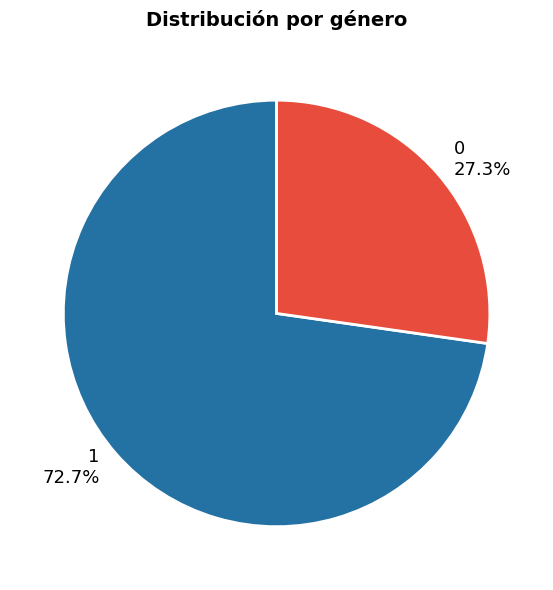

In [14]:
# Distribución por género
gen_counts = data["Gender"].value_counts()
gen_pct    = (gen_counts / len(data) * 100).round(1)

print("── Distribución por género ──")
for g, n, p in zip(gen_counts.index, gen_counts.values, gen_pct.values):
    print(f"  {g}: {n} estudiantes ({p}%)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(gen_counts.values,
       labels=[f"{g}\n{p}%" for g, p in zip(gen_counts.index, gen_pct.values)],
       colors=["#2471A3", "#E74C3C"],
       startangle=90,
       wedgeprops=dict(linewidth=2, edgecolor="white"),
       textprops=dict(fontsize=13))
ax.set_title("Distribución por género", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("genero_pie.png", bbox_inches='tight', dpi=200)
plt.show()

DESBALANCE POR CARRERA:
Carrera
3.0    256
1.0    159
2.0     71
Name: count, dtype: int64


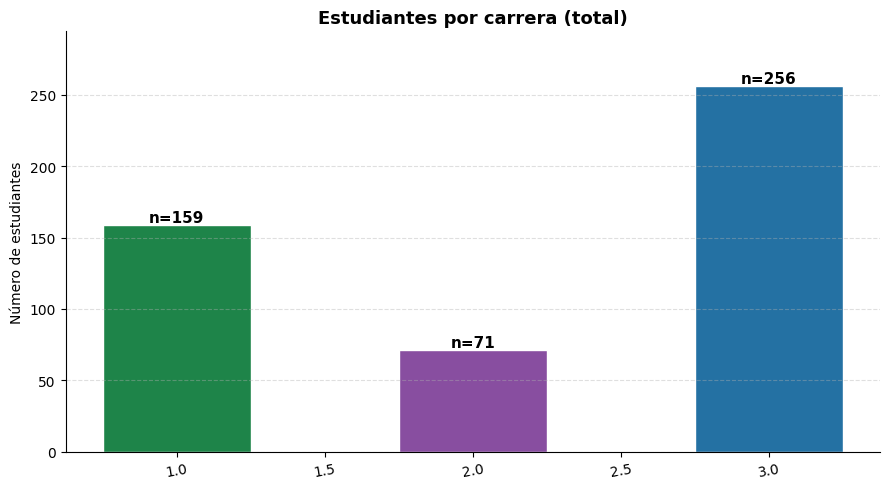

In [15]:
# ── Distribución por carrera (referencia para normalización) ──
print("DESBALANCE POR CARRERA:")
print(data["Carrera"].value_counts())

# ── Gráfica con las 4 carreras (ANTES de excluir) ────────────
carr_counts  = data["Carrera"].value_counts()
colores_carr = ["#2471A3", "#1E8449", "#884EA0", "#B7950B"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(carr_counts.index, carr_counts.values,
              color=colores_carr, edgecolor="white", width=0.5)

for bar, val in zip(bars, carr_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f"n={val}", ha='center', fontsize=11, fontweight="bold")

ax.set_title("Estudiantes por carrera (total)", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de estudiantes")
ax.set_ylim(0, carr_counts.max() * 1.15)
ax.tick_params(axis='x', rotation=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("barras_carrera.png", bbox_inches='tight', dpi=150)
plt.show()

DESBALANCE POR CARRERA:
Carrera
3.0    256
1.0    159
2.0     71
Name: count, dtype: int64


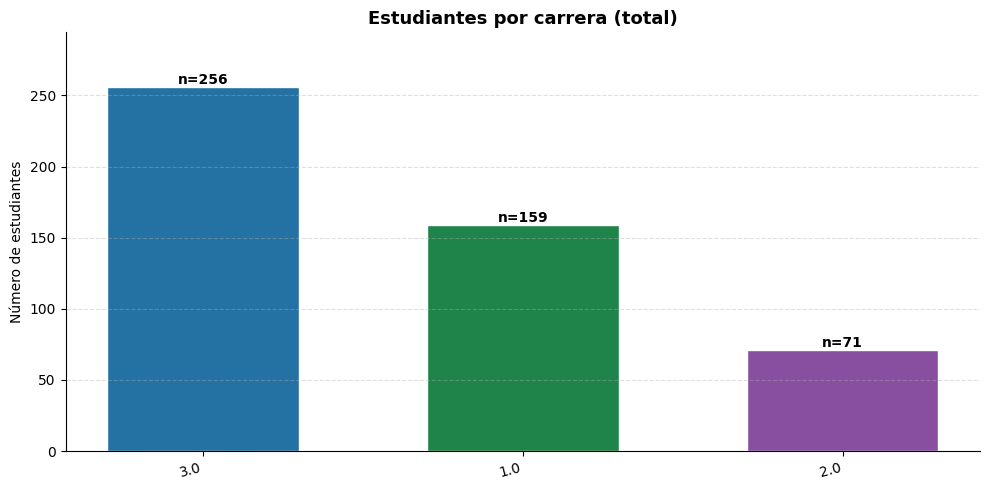

Valores únicos en Semestre: [ 3.  1.  6.  5.  4. nan  2.  8.]


In [16]:
# ── Distribución por carrera (referencia para normalización) ──
print("DESBALANCE POR CARRERA:")
print(data["Carrera"].value_counts())

# ── Gráfica con las carreras (ANTES de excluir) ────────────
# Obtener todas las carreras
carr_counts = data["Carrera"].value_counts()

# Crear una paleta de colores dinámica
colores_carr = ["#2471A3", "#1E8449", "#884EA0", "#B7950B", "#D35400", "#E67E22"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(carr_counts)), carr_counts.values,
              color=colores_carr[:len(carr_counts)], edgecolor="white", width=0.6)

# Etiquetas
ax.set_xticks(range(len(carr_counts)))
ax.set_xticklabels(carr_counts.index, rotation=15, ha='right')

for bar, val in zip(bars, carr_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f"n={val}", ha='center', fontsize=10, fontweight="bold")

ax.set_title("Estudiantes por carrera (total)", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de estudiantes")
ax.set_ylim(0, carr_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("barras_carrera.png", bbox_inches='tight', dpi=150)
plt.show()

# ── Distribución por semestre ─────────────────────────────────
# Orden correcto de los semestres en español
orden_semestre = ["Primero", "Segundo", "Tercero", "Cuarto", 
                  "Quinto", "Sexto", "Séptimo", "Octavo"]

# Verificar que la columna existe
if "Semestre" not in data.columns:
    print("Columnas disponibles:", data.columns.tolist())
else:
    # Contar y reordenar
    sem_counts = data["Semestre"].value_counts().reindex(orden_semestre).fillna(0)
    
    # Filtrar solo los que tienen valores > 0
    sem_counts = sem_counts[sem_counts > 0]
    
    if len(sem_counts) == 0:
        print("Valores únicos en Semestre:", data["Semestre"].unique())
    else:
        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.bar(range(len(sem_counts)), sem_counts.values,
                      color="#2471A3", edgecolor="white", width=0.6)
        
        # Etiquetas personalizadas
        ax.set_xticks(range(len(sem_counts)))
        ax.set_xticklabels(sem_counts.index, rotation=45, ha='right')
        
        for bar, val in zip(bars, sem_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f"n={int(val)}", ha='center', fontsize=9, fontweight="bold")
        
        ax.set_title("Estudiantes por semestre", fontsize=13, fontweight="bold")
        ax.set_ylabel("Número de estudiantes")
        
        # Usar max() seguro
        max_val = sem_counts.max()
        if pd.notna(max_val) and max_val > 0:
            ax.set_ylim(0, max_val * 1.15)
        else:
            ax.set_ylim(0, 1)
            
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.savefig("barras_semestre.png", bbox_inches='tight', dpi=150)
        plt.show()
        
        # Mostrar estadísticas
        print("\n📊 Distribución por semestre:")
        for sem, count in sem_counts.items():
            print(f"  {sem}: {count} estudiantes ({count/len(data)*100:.1f}%)")

In [17]:
# Asumiendo que 'data' es tu DataFrame original
# Primero, creamos una función para clasificar por gama
def clasificar_gama(row):
    """
    Clasifica el dispositivo en ALTA, MEDIA o BAJA gama basado en la Marca y Modelo.
    """
    marca = str(row['Marca']).lower()
    modelo = str(row['Modelo']).lower()

    # --- GAMA ALTA (Precio de referencia: +15,000 MXN) ---
    if marca == 'apple':
        # Cualquier iPhone es considerado alta gama
        return 'ALTA'
    if marca == 'samsung' and ('s' in modelo or 'ultra' in modelo or 'z flip' in modelo):
        # Samsung: Serie S, Ultra o Z Flip
        return 'ALTA'
    if marca == 'google' and 'pixel' in modelo:
        # Google Pixel
        return 'ALTA'
    if marca == 'xiaomi' and ('ultra' in modelo or 'pro' in modelo and '14' in modelo or '15' in modelo):
        # Xiaomi: Solo los últimos modelos Ultra o Pro
        return 'ALTA'

    # --- GAMA MEDIA (Precio de referencia: 5,000 - 14,999 MXN) ---
    if marca in ['xiaomi', 'motorola', 'honor', 'oppo', 'realme', 'vivo']:
        if 'pro' in modelo or 'edge' in modelo or 'note' in modelo:
            return 'MEDIA'  # Modelos Pro, Edge o Note de estas marcas
        return 'MEDIA'      # La mayoría de estas marcas se consideran media gama
    if marca == 'samsung' and ('a' in modelo and not 's' in modelo):
        # Samsung: Serie A (pero no la S)
        return 'MEDIA'
    if marca == 'huawei':
        return 'MEDIA'

    # --- GAMA BAJA (Precio de referencia: < 5,000 MXN) ---
    # Todo lo que no ha sido clasificado como ALTA o MEDIA
    return 'BAJA'

# Aplicar la clasificación
data['Gama_Equipo'] = data.apply(clasificar_gama, axis=1)

# Mostrar la distribución
print("📊 Distribución por Gama de Equipo:")
print(data['Gama_Equipo'].value_counts())

# Opcional: Agregar una columna con el precio estimado basado en la gama
precios_estimados = {
    'ALTA': 18000,
    'MEDIA': 8000,
    'BAJA': 3500
}
data['Precio_Estimado_MXN'] = data['Gama_Equipo'].map(precios_estimados)

# Guardar el archivo con la nueva información
data.to_csv('data_con_gama.csv', index=False, encoding='utf-8-sig')
print("Archivo 'data_con_gama.csv' creado.")
print("\nEjemplo de los primeros registros:")
print(data[['Marca', 'Modelo', 'Gama_Equipo', 'Precio_Estimado_MXN']].head(10))

📊 Distribución por Gama de Equipo:
Gama_Equipo
MEDIA    234
ALTA     220
BAJA      34
Name: count, dtype: int64
Archivo 'data_con_gama.csv' creado.

Ejemplo de los primeros registros:
       Marca             Modelo Gama_Equipo  Precio_Estimado_MXN
0      Honor          Honor X7a       MEDIA                 8000
1      Apple  iPhone 15 pro max        ALTA                18000
2      Apple  iPhone 16 pro max        ALTA                18000
3      Apple  iPhone 16 pro max        ALTA                18000
4      Apple  iPhone 13 pro max        ALTA                18000
5     Xiaomi            14T Pro        ALTA                18000
6       Otra          Cubot P80        BAJA                 3500
7    Samsung         Galaxy A15       MEDIA                 8000
8   Motorola               G60s       MEDIA                 8000
10      Otra            Infinix        BAJA                 3500


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import re
import warnings
warnings.filterwarnings('ignore')

# ── 1. VERIFICAR QUE LOS DATOS ESTÁN LISTOS ──────────────────────────────
print("📊 VERIFICACIÓN DE DATOS")
print("="*50)
print(f"Shape de datos: {data.shape}")
print(f"\nColumnas disponibles:\n{data.columns.tolist()}")
print(f"\nTipos de datos:")
print(data.dtypes)

# ── 2. SELECCIONAR VARIABLES NUMÉRICAS PARA PCA ──────────────────────────
print("\n" + "="*50)
print("📊 SELECCIÓN DE VARIABLES NUMÉRICAS")
print("="*50)

# Variables que ya convertiste a numéricas
variables_numericas = [
    'Semestre',      # 1-8
    'Carrera',       # 1-3
    'Regular',       # 0-1
    'Hermanos',      # 0-1
    'Capacidad',     # GB (32,64,128,256,512,1024,2048)
    'Metodo_pago',   # 0-1
    'Tiempo',        # 0-4 (años aproximados)
    'Estado',        # 0-1
    'Gender',        # 0-1
    'Trabajo',       # 0-1
    'Edad'           # Edad en años
]

# Verificar que todas las variables existen
variables_disponibles = [var for var in variables_numericas if var in data.columns]
variables_faltantes = [var for var in variables_numericas if var not in data.columns]

print(f"Variables disponibles: {len(variables_disponibles)}")
print(variables_disponibles)

if variables_faltantes:
    print(f"\n⚠️ Variables faltantes: {variables_faltantes}")

# ── 3. CREAR DATAFRAME CON VARIABLES NUMÉRICAS ───────────────────────────
df_numerico = data[variables_disponibles].copy()

# Convertir a numérico forzando errores
for col in df_numerico.columns:
    df_numerico[col] = pd.to_numeric(df_numerico[col], errors='coerce')

print(f"\nShape del DataFrame numérico: {df_numerico.shape}")
print(f"\nValores nulos por columna:")
print(df_numerico.isnull().sum())

# ── 4. MANEJAR VALORES NULOS ────────────────────────────────────────────
print("\n" + "="*50)
print("📊 MANEJO DE VALORES NULOS")
print("="*50)

# Ver porcentaje de nulos por columna
nulos_porcentaje = (df_numerico.isnull().sum() / len(df_numerico)) * 100
print("Porcentaje de nulos por columna:")
print(nulos_porcentaje[nulos_porcentaje > 0])

# Imputar valores nulos con la media
imputer = SimpleImputer(strategy='mean')
df_imputado = pd.DataFrame(
    imputer.fit_transform(df_numerico),
    columns=df_numerico.columns,
    index=df_numerico.index
)

print(f"\n✅ Nulos después de imputación: {df_imputado.isnull().sum().sum()}")

# ── 5. ESTANDARIZAR DATOS ────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 ESTANDARIZACIÓN DE DATOS")
print("="*50)

scaler = StandardScaler()
df_estandarizado = scaler.fit_transform(df_imputado)
df_estandarizado = pd.DataFrame(
    df_estandarizado,
    columns=df_imputado.columns,
    index=df_imputado.index
)

print("Estadísticas después de estandarizar:")
print(df_estandarizado.describe().round(3))

# ── 6. APLICAR PCA ──────────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 APLICANDO PCA")
print("="*50)

# Aplicar PCA
pca = PCA()
componentes = pca.fit_transform(df_estandarizado)

# Crear DataFrame con los componentes
nombres_componentes = [f'PC{i+1}' for i in range(componentes.shape[1])]
df_componentes = pd.DataFrame(
    componentes,
    columns=nombres_componentes,
    index=df_imputado.index
)

print(f"Shape de los componentes: {df_componentes.shape}")

# ── 7. ANALIZAR VARIANZA EXPLICADA ──────────────────────────────────────
print("\n" + "="*50)
print("📊 VARIANZA EXPLICADA")
print("="*50)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
print("-" * 40)
for i, (var, var_acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"PC{i+1:2d}: {var:6.2%} | Acumulado: {var_acum:6.2%}")

print(f"\n📌 Para explicar el 80% de varianza: {np.argmax(varianza_acumulada >= 0.80) + 1} componentes")
print(f"📌 Para explicar el 90% de varianza: {np.argmax(varianza_acumulada >= 0.90) + 1} componentes")
print(f"📌 Para explicar el 95% de varianza: {np.argmax(varianza_acumulada >= 0.95) + 1} componentes")

# ── 8. VISUALIZACIONES ──────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GENERANDO VISUALIZACIONES")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico de varianza explicada (Scree plot)
axes[0, 0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, 
               alpha=0.6, color='steelblue', label='Individual')
axes[0, 0].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 
                'ro-', linewidth=2, markersize=6, label='Acumulada')
axes[0, 0].axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95%')
axes[0, 0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90%')
axes[0, 0].axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='80%')
axes[0, 0].set_xlabel('Componente Principal')
axes[0, 0].set_ylabel('Varianza Explicada')
axes[0, 0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(varianza_explicada)+1))

# Matriz de correlación
corr_matrix = df_imputado.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[0, 1], square=True, cbar_kws={"shrink": 0.8})
axes[0, 1].set_title('Matriz de Correlación entre Variables', fontsize=12, fontweight='bold')

# Carga de variables en PC1 y PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=df_imputado.columns
)

# Graficar cargas
axes[1, 0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1, 0].axvline(0, color='gray', linewidth=0.5, linestyle='--')

for i, var in enumerate(loadings.index):
    axes[1, 0].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1],
                     head_width=0.03, head_length=0.03, fc='blue', ec='blue', alpha=0.7)
    axes[1, 0].text(loadings.iloc[i, 0]*1.1, loadings.iloc[i, 1]*1.1, 
                    var, fontsize=9, fontweight='bold')

# Ajustar límites
max_loading = max(abs(loadings.values).max(), 0.5)
axes[1, 0].set_xlim(-max_loading*1.2, max_loading*1.2)
axes[1, 0].set_ylim(-max_loading*1.2, max_loading*1.2)
axes[1, 0].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[1, 0].set_title('Carga de Variables en PC1 y PC2', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot de las primeras dos componentes
scatter = axes[1, 1].scatter(df_componentes['PC1'], df_componentes['PC2'], 
                            alpha=0.6, c=df_componentes['PC1'], cmap='viridis', 
                            s=30, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[1, 1].set_title('Proyección de Estudiantes en PC1 vs PC2', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='PC1 Score')

plt.tight_layout()
plt.savefig('pca_analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. ANÁLISIS DE CARGAS POR VARIABLE ─────────────────────────────────
print("\n" + "="*50)
print("📊 ANÁLISIS DE CARGAS (LOADINGS)")
print("="*50)

# Cargas para los primeros 3 componentes
for pc in range(3):
    print(f"\n📌 Componente {pc+1} (Varianza: {varianza_explicada[pc]:.2%}):")
    cargas_pc = loadings.iloc[:, pc].sort_values(key=abs, ascending=False)
    for var, carga in cargas_pc.head(5).items():
        direccion = "POSITIVA" if carga > 0 else "NEGATIVA"
        print(f"  {var:15s}: {carga:7.3f} ({direccion})")

# ── 10. INTERPRETACIÓN DE CADA COMPONENTE ──────────────────────────────
print("\n" + "="*50)
print("📊 INTERPRETACIÓN DE COMPONENTES PRINCIPALES")
print("="*50)

# Interpretación basada en cargas altas
for pc in range(min(3, len(loadings.columns))):
    print(f"\n🔍 Componente {pc+1} (Explica {varianza_explicada[pc]:.1%} de varianza):")
    
    # Variables con carga positiva alta
    positivas = loadings.iloc[:, pc][loadings.iloc[:, pc] > 0.3].sort_values(ascending=False)
    if len(positivas) > 0:
        print(f"  ✓ Variables que aumentan juntas:")
        for var, carga in positivas.items():
            print(f"    - {var}: {carga:.3f}")
    
    # Variables con carga negativa alta
    negativas = loadings.iloc[:, pc][loadings.iloc[:, pc] < -0.3].sort_values()
    if len(negativas) > 0:
        print(f"  ✗ Variables que se comportan inversamente:")
        for var, carga in negativas.items():
            print(f"    - {var}: {carga:.3f}")

# ── 11. GUARDAR RESULTADOS ─────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GUARDANDO RESULTADOS")
print("="*50)

# Guardar componentes principales
df_componentes.to_csv("componentes_principales.csv", index=False)
print("✅ Componentes principales guardados en 'componentes_principales.csv'")

# Guardar cargas de variables
loadings.to_csv("cargas_variables.csv")
print("✅ Cargas de variables guardadas en 'cargas_variables.csv'")

# Guardar varianza explicada
df_varianza = pd.DataFrame({
    'Componente': range(1, len(varianza_explicada)+1),
    'Varianza_Individual': varianza_explicada,
    'Varianza_Acumulada': varianza_acumulada
})
df_varianza.to_csv("varianza_explicada.csv", index=False)
print("✅ Varianza explicada guardada en 'varianza_explicada.csv'")

# Guardar datos estandarizados (opcional)
df_estandarizado.to_csv("datos_estandarizados_pca.csv", index=False)
print("✅ Datos estandarizados guardados en 'datos_estandarizados_pca.csv'")

print("\n" + "="*50)
print("🎉 PCA COMPLETADO EXITOSAMENTE")
print("="*50)
print("\n📌 Resumen:")
print(f"  - Total de variables analizadas: {len(variables_disponibles)}")
print(f"  - Total de observaciones: {len(df_imputado)}")
print(f"  - Componentes generados: {len(loadings.columns)}")
print(f"  - Varianza explicada por PC1: {varianza_explicada[0]:.1%}")
print(f"  - Varianza explicada por PC2: {varianza_explicada[1]:.1%}")
print(f"  - Varianza acumulada primeros 3 componentes: {varianza_acumulada[2]:.1%}")

ModuleNotFoundError: No module named 'seaborn'

📊 VERIFICACIÓN DE DATOS
Shape de datos: (488, 19)

Columnas disponibles:
['Marca temporal', 'Correo', 'Semestre', 'Carrera', 'Regular', 'Ciudad', 'Hermanos', 'Marca', 'Modelo', 'Capacidad', 'Metodo_pago', 'Tiempo', 'Estado', 'Gender', 'Trabajo', 'Edad', 'Telefono_futuro', 'Gama_Equipo', 'Precio_Estimado_MXN']

Tipos de datos:
Marca temporal             str
Correo                     str
Semestre               float64
Carrera                float64
Regular                float64
Ciudad                     str
Hermanos               float64
Marca                      str
Modelo                     str
Capacidad                int64
Metodo_pago              int64
Tiempo                   int64
Estado                   int64
Gender                   int64
Trabajo                  int64
Edad                    object
Telefono_futuro            str
Gama_Equipo                str
Precio_Estimado_MXN      int64
dtype: object

📊 SELECCIÓN DE VARIABLES NUMÉRICAS
Variables disponibles: 11
['Semes

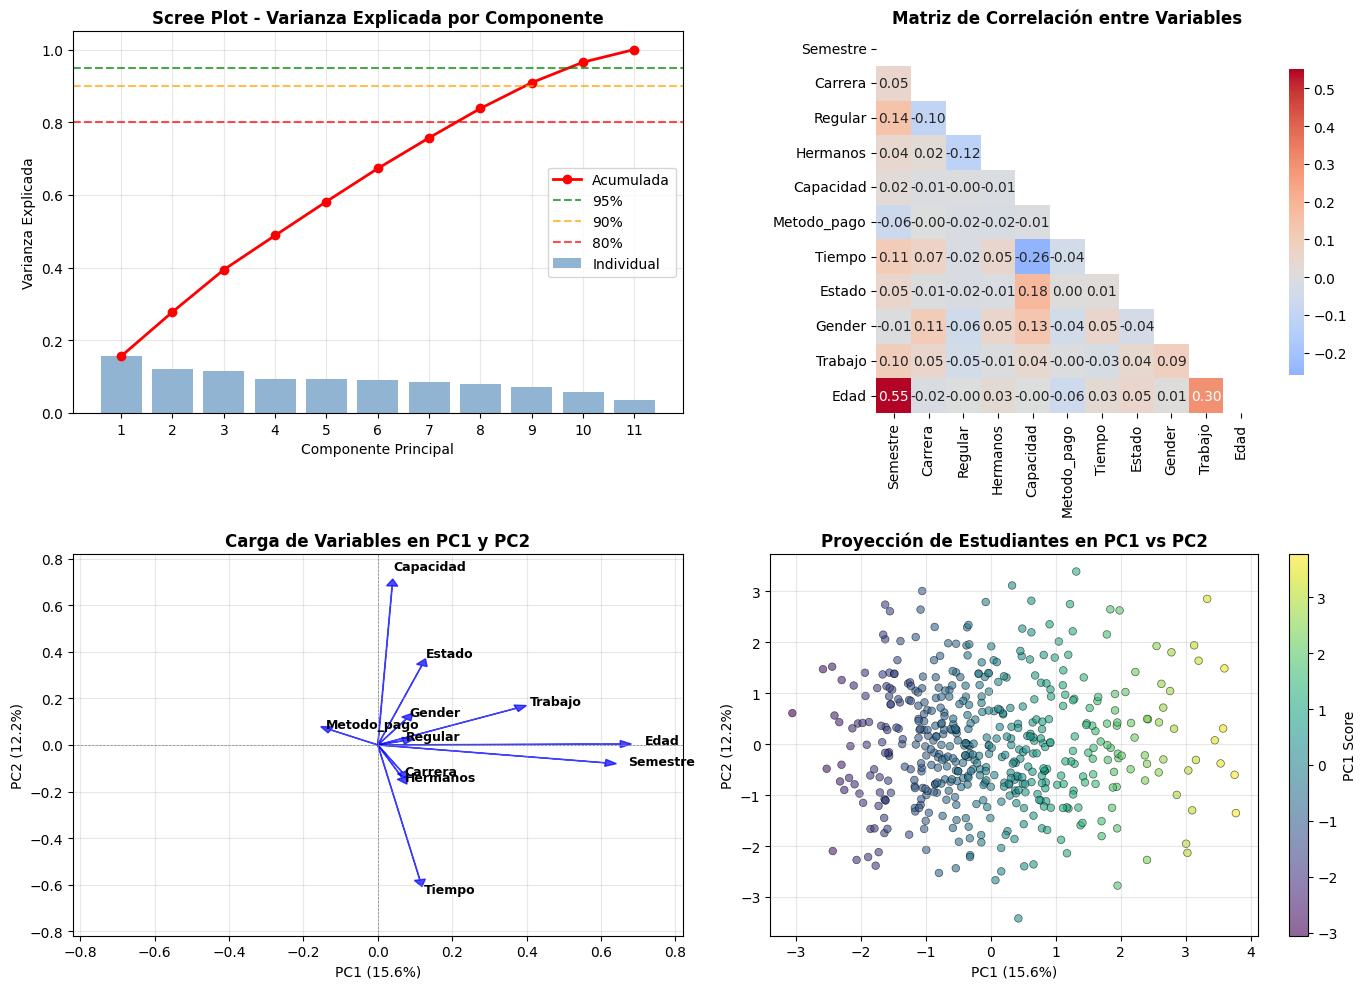


📊 ANÁLISIS DE CARGAS (LOADINGS)
Analizando los primeros 3 componentes

📌 Componente 1 (Varianza: 15.59%):
  Edad           :   0.652 (POSITIVA)
  Semestre       :   0.611 (POSITIVA)
  Trabajo        :   0.372 (POSITIVA)
  Metodo_pago    :  -0.127 (NEGATIVA)
  Estado         :   0.118 (POSITIVA)

📌 Componente 2 (Varianza: 12.18%):
  Capacidad      :   0.683 (POSITIVA)
  Tiempo         :  -0.579 (NEGATIVA)
  Estado         :   0.342 (POSITIVA)
  Trabajo        :   0.157 (POSITIVA)
  Hermanos       :  -0.141 (NEGATIVA)

📌 Componente 3 (Varianza: 11.62%):
  Regular        :   0.553 (POSITIVA)
  Gender         :  -0.502 (NEGATIVA)
  Carrera        :  -0.461 (NEGATIVA)
  Hermanos       :  -0.352 (NEGATIVA)
  Trabajo        :  -0.199 (NEGATIVA)

📊 INTERPRETACIÓN DE COMPONENTES PRINCIPALES

🔍 Componente 1 (Explica 15.6% de varianza):
  ✓ Variables que aumentan juntas:
    - Edad: 0.652
    - Semestre: 0.611
    - Trabajo: 0.372

🔍 Componente 2 (Explica 12.2% de varianza):
  ✓ Variables que au

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import re
import warnings
warnings.filterwarnings('ignore')

# ── 1. VERIFICAR QUE LOS DATOS ESTÁN LISTOS ──────────────────────────────
print("📊 VERIFICACIÓN DE DATOS")
print("="*50)
print(f"Shape de datos: {data.shape}")
print(f"\nColumnas disponibles:\n{data.columns.tolist()}")
print(f"\nTipos de datos:")
print(data.dtypes)

# ── 2. SELECCIONAR VARIABLES NUMÉRICAS PARA PCA ──────────────────────────
print("\n" + "="*50)
print("📊 SELECCIÓN DE VARIABLES NUMÉRICAS")
print("="*50)

# Variables que ya convertiste a numéricas
variables_numericas = [
    'Semestre',      # 1-8
    'Carrera',       # 1-3
    'Regular',       # 0-1
    'Hermanos',      # 0-1
    'Capacidad',     # GB (32,64,128,256,512,1024,2048)
    'Metodo_pago',   # 0-1
    'Tiempo',        # 0-4 (años aproximados)
    'Estado',        # 0-1
    'Gender',        # 0-1
    'Trabajo',       # 0-1
    'Edad'           # Edad en años
]

# Verificar que todas las variables existen
variables_disponibles = [var for var in variables_numericas if var in data.columns]
variables_faltantes = [var for var in variables_numericas if var not in data.columns]

print(f"Variables disponibles: {len(variables_disponibles)}")
print(variables_disponibles)

if variables_faltantes:
    print(f"\n⚠️ Variables faltantes: {variables_faltantes}")

# ── 3. CREAR DATAFRAME CON VARIABLES NUMÉRICAS ───────────────────────────
df_numerico = data[variables_disponibles].copy()

# Convertir a numérico forzando errores
for col in df_numerico.columns:
    df_numerico[col] = pd.to_numeric(df_numerico[col], errors='coerce')

print(f"\nShape del DataFrame numérico: {df_numerico.shape}")
print(f"\nValores nulos por columna:")
print(df_numerico.isnull().sum())

# ── 4. MANEJAR VALORES NULOS ────────────────────────────────────────────
print("\n" + "="*50)
print("📊 MANEJO DE VALORES NULOS")
print("="*50)

# Ver porcentaje de nulos por columna
nulos_porcentaje = (df_numerico.isnull().sum() / len(df_numerico)) * 100
print("Porcentaje de nulos por columna:")
print(nulos_porcentaje[nulos_porcentaje > 0])

# Imputar valores nulos con la media
imputer = SimpleImputer(strategy='mean')
df_imputado = pd.DataFrame(
    imputer.fit_transform(df_numerico),
    columns=df_numerico.columns,
    index=df_numerico.index
)

print(f"\n✅ Nulos después de imputación: {df_imputado.isnull().sum().sum()}")

# ── 5. ESTANDARIZAR DATOS ────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 ESTANDARIZACIÓN DE DATOS")
print("="*50)

scaler = StandardScaler()
df_estandarizado = scaler.fit_transform(df_imputado)
df_estandarizado = pd.DataFrame(
    df_estandarizado,
    columns=df_imputado.columns,
    index=df_imputado.index
)

print("Estadísticas después de estandarizar:")
print(df_estandarizado.describe().round(3))

# ── 6. APLICAR PCA ──────────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 APLICANDO PCA")
print("="*50)

# Aplicar PCA
pca = PCA()
componentes = pca.fit_transform(df_estandarizado)

# Crear DataFrame con los componentes
nombres_componentes = [f'PC{i+1}' for i in range(componentes.shape[1])]
df_componentes = pd.DataFrame(
    componentes,
    columns=nombres_componentes,
    index=df_imputado.index
)

print(f"Shape de los componentes: {df_componentes.shape}")
print(f"Número de componentes generados: {len(nombres_componentes)}")

# ── 7. ANALIZAR VARIANZA EXPLICADA ──────────────────────────────────────
print("\n" + "="*50)
print("📊 VARIANZA EXPLICADA")
print("="*50)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
print("-" * 40)
for i, (var, var_acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"PC{i+1:2d}: {var:6.2%} | Acumulado: {var_acum:6.2%}")

print(f"\n📌 Para explicar el 80% de varianza: {np.argmax(varianza_acumulada >= 0.80) + 1 if any(varianza_acumulada >= 0.80) else len(varianza_acumulada)} componentes")
print(f"📌 Para explicar el 90% de varianza: {np.argmax(varianza_acumulada >= 0.90) + 1 if any(varianza_acumulada >= 0.90) else len(varianza_acumulada)} componentes")
print(f"📌 Para explicar el 95% de varianza: {np.argmax(varianza_acumulada >= 0.95) + 1 if any(varianza_acumulada >= 0.95) else len(varianza_acumulada)} componentes")

# ── 8. VISUALIZACIONES ──────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GENERANDO VISUALIZACIONES")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico de varianza explicada (Scree plot)
axes[0, 0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, 
               alpha=0.6, color='steelblue', label='Individual')
axes[0, 0].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 
                'ro-', linewidth=2, markersize=6, label='Acumulada')
axes[0, 0].axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95%')
axes[0, 0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90%')
axes[0, 0].axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='80%')
axes[0, 0].set_xlabel('Componente Principal')
axes[0, 0].set_ylabel('Varianza Explicada')
axes[0, 0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(varianza_explicada)+1))

# Matriz de correlación
corr_matrix = df_imputado.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[0, 1], square=True, cbar_kws={"shrink": 0.8})
axes[0, 1].set_title('Matriz de Correlación entre Variables', fontsize=12, fontweight='bold')

# Carga de variables en PC1 y PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=df_imputado.columns
)

# Graficar cargas
axes[1, 0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1, 0].axvline(0, color='gray', linewidth=0.5, linestyle='--')

for i, var in enumerate(loadings.index):
    axes[1, 0].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1],
                     head_width=0.03, head_length=0.03, fc='blue', ec='blue', alpha=0.7)
    axes[1, 0].text(loadings.iloc[i, 0]*1.1, loadings.iloc[i, 1]*1.1, 
                    var, fontsize=9, fontweight='bold')

# Ajustar límites
max_loading = max(abs(loadings.values).max(), 0.5)
axes[1, 0].set_xlim(-max_loading*1.2, max_loading*1.2)
axes[1, 0].set_ylim(-max_loading*1.2, max_loading*1.2)
axes[1, 0].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[1, 0].set_title('Carga de Variables en PC1 y PC2', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot de las primeras dos componentes
scatter = axes[1, 1].scatter(df_componentes['PC1'], df_componentes['PC2'], 
                            alpha=0.6, c=df_componentes['PC1'], cmap='viridis', 
                            s=30, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel(f'PC1 ({varianza_explicada[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({varianza_explicada[1]:.1%})')
axes[1, 1].set_title('Proyección de Estudiantes en PC1 vs PC2', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='PC1 Score')

plt.tight_layout()
plt.savefig('pca_analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. ANÁLISIS DE CARGAS POR VARIABLE ─────────────────────────────────
print("\n" + "="*50)
print("📊 ANÁLISIS DE CARGAS (LOADINGS)")
print("="*50)

# Determinar cuántos componentes analizar (máximo 3 o el número disponible)
n_componentes_analizar = min(3, len(varianza_explicada))
print(f"Analizando los primeros {n_componentes_analizar} componentes")

# Cargas para los primeros componentes
for pc in range(n_componentes_analizar):
    print(f"\n📌 Componente {pc+1} (Varianza: {varianza_explicada[pc]:.2%}):")
    # Usar iloc con el índice correcto
    if pc == 0:
        cargas_pc = loadings['PC1'].sort_values(key=abs, ascending=False)
    elif pc == 1:
        cargas_pc = loadings['PC2'].sort_values(key=abs, ascending=False)
    else:
        # Para PC3, necesitamos obtener las cargas del tercer componente
        if len(pca.components_) > 2:
            cargas_pc3 = pd.Series(pca.components_[2], index=df_imputado.columns)
            cargas_pc = cargas_pc3.sort_values(key=abs, ascending=False)
        else:
            print(f"  No hay suficiente componentes para PC{pc+1}")
            continue
    
    for var, carga in cargas_pc.head(5).items():
        direccion = "POSITIVA" if carga > 0 else "NEGATIVA"
        print(f"  {var:15s}: {carga:7.3f} ({direccion})")

# ── 10. INTERPRETACIÓN DE CADA COMPONENTE ──────────────────────────────
print("\n" + "="*50)
print("📊 INTERPRETACIÓN DE COMPONENTES PRINCIPALES")
print("="*50)

# Interpretación basada en cargas altas
for pc in range(n_componentes_analizar):
    print(f"\n🔍 Componente {pc+1} (Explica {varianza_explicada[pc]:.1%} de varianza):")
    
    # Obtener las cargas para este componente
    if pc == 0:
        cargas = loadings['PC1']
    elif pc == 1:
        cargas = loadings['PC2']
    else:
        cargas = pd.Series(pca.components_[2], index=df_imputado.columns)
    
    # Variables con carga positiva alta
    positivas = cargas[cargas > 0.3].sort_values(ascending=False)
    if len(positivas) > 0:
        print(f"  ✓ Variables que aumentan juntas:")
        for var, carga in positivas.items():
            print(f"    - {var}: {carga:.3f}")
    
    # Variables con carga negativa alta
    negativas = cargas[cargas < -0.3].sort_values()
    if len(negativas) > 0:
        print(f"  ✗ Variables que se comportan inversamente:")
        for var, carga in negativas.items():
            print(f"    - {var}: {carga:.3f}")

# ── 11. GUARDAR RESULTADOS ─────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GUARDANDO RESULTADOS")
print("="*50)

# Guardar componentes principales
df_componentes.to_csv("componentes_principales.csv", index=False)
print("✅ Componentes principales guardados en 'componentes_principales.csv'")

# Guardar cargas de variables
loadings.to_csv("cargas_variables.csv")
print("✅ Cargas de variables guardadas en 'cargas_variables.csv'")

# Guardar varianza explicada
df_varianza = pd.DataFrame({
    'Componente': range(1, len(varianza_explicada)+1),
    'Varianza_Individual': varianza_explicada,
    'Varianza_Acumulada': varianza_acumulada
})
df_varianza.to_csv("varianza_explicada.csv", index=False)
print("✅ Varianza explicada guardada en 'varianza_explicada.csv'")

# Guardar datos estandarizados (opcional)
df_estandarizado.to_csv("datos_estandarizados_pca.csv", index=False)
print("✅ Datos estandarizados guardados en 'datos_estandarizados_pca.csv'")

print("\n" + "="*50)
print("🎉 PCA COMPLETADO EXITOSAMENTE")
print("="*50)
print("\n📌 Resumen:")
print(f"  - Total de variables analizadas: {len(variables_disponibles)}")
print(f"  - Total de observaciones: {len(df_imputado)}")
print(f"  - Componentes generados: {len(loadings.columns)}")
print(f"  - Varianza explicada por PC1: {varianza_explicada[0]:.1%}")
if len(varianza_explicada) > 1:
    print(f"  - Varianza explicada por PC2: {varianza_explicada[1]:.1%}")
if len(varianza_explicada) > 2:
    print(f"  - Varianza acumulada primeros 3 componentes: {varianza_acumulada[2]:.1%}")